<figure>
<center>
<img src="https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png"/>
</center></figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Métodos Predictivos**
### Cátedra: Bianco
#### **Regresión Logística**

## Ensambles

In [1]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Descarga directa desde un repositorio verificado con la versión ampliada de 2500 registros
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df_base = pd.read_csv(url)

df = df_base.copy()

# # Renombramos columnas
df.columns = ['Edad', 'Sexo', 'IMC', 'Hijos', 'Fumador', 'Region', 'Cargos_Medicos']

# Convertimos las variables categóricas de texto a numéricas (0 y 1) automáticamente
# Mantenemos el pretratamiento manual en CERO absoluto.
df = pd.get_dummies(df, columns=['Sexo', 'Fumador'], drop_first=True, dtype=int)
df = pd.get_dummies(df, columns=['Region'], drop_first=False, dtype=int)


print("\n--- Estructura del Dataset de Seguros para Ensambles ---")
print(f"Dimensiones reales: {df.shape[0]} filas x {df.shape[1]} columns")
print("\nPrimeros registros (Base 100% numérica lista para modelar):")
df.head()


--- Estructura del Dataset de Seguros para Ensambles ---
Dimensiones reales: 1338 filas x 10 columns

Primeros registros (Base 100% numérica lista para modelar):


,Edad,IMC,Hijos,Cargos_Medicos,Sexo_male,Fumador_yes,Region_northeast,Region_northwest,Region_southeast,Region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,0,1
1,18,33.770,1,1725.55230,1,0,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,0,1,0
3,33,22.705,0,21984.47061,1,0,0,1,0,0
4,32,28.880,0,3866.85520,1,0,0,1,0,0


In [3]:
df_base

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
# Resumen estadístico completo de todas las variables numéricas
df_base.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [5]:
print("--- PORCENTAJE DE PACIENTES POR REGIÓN ---")
print(df_base['region'].value_counts(normalize=True) * 100)

--- PORCENTAJE DE PACIENTES POR REGIÓN ---
region
southeast    27.204783
southwest    24.289985
northwest    24.289985
northeast    24.215247
Name: proportion, dtype: float64


In [6]:
print("--- PORCENTAJE DE FUMADORES ---")
print(df['Fumador_yes'].value_counts(normalize=True) * 100)

print("\n--- PORCENTAJE DE HOMBRES Y MUJERES ---")
print(df['Sexo_male'].value_counts(normalize=True) * 100)

--- PORCENTAJE DE FUMADORES ---
Fumador_yes
0    79.521674
1    20.478326
Name: proportion, dtype: float64

--- PORCENTAJE DE HOMBRES Y MUJERES ---
Sexo_male
1    50.523169
0    49.476831
Name: proportion, dtype: float64


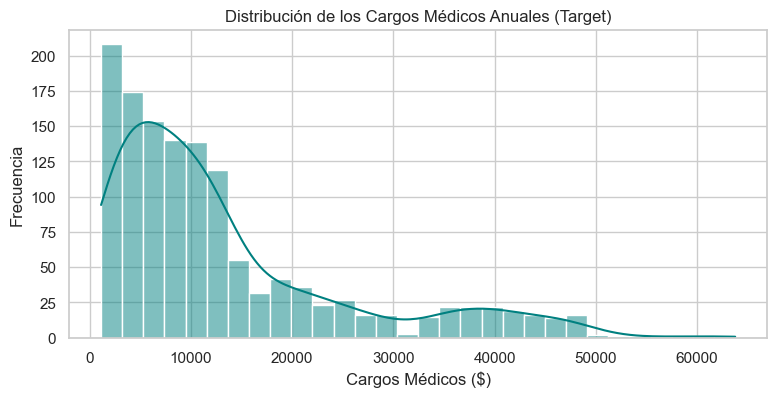

In [7]:
# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 4))

# Histograma con curva de densidad integrada
sns.histplot(data=df, x='Cargos_Medicos', kde=True, color='teal')
plt.title('Distribución de los Cargos Médicos Anuales (Target)', fontsize=12)
plt.xlabel('Cargos Médicos ($)')
plt.ylabel('Frecuencia')
plt.show()

In [8]:
print(df.isnull().sum())

Edad                0
IMC                 0
Hijos               0
Cargos_Medicos      0
Sexo_male           0
Fumador_yes         0
Region_northeast    0
Region_northwest    0
Region_southeast    0
Region_southwest    0
dtype: int64


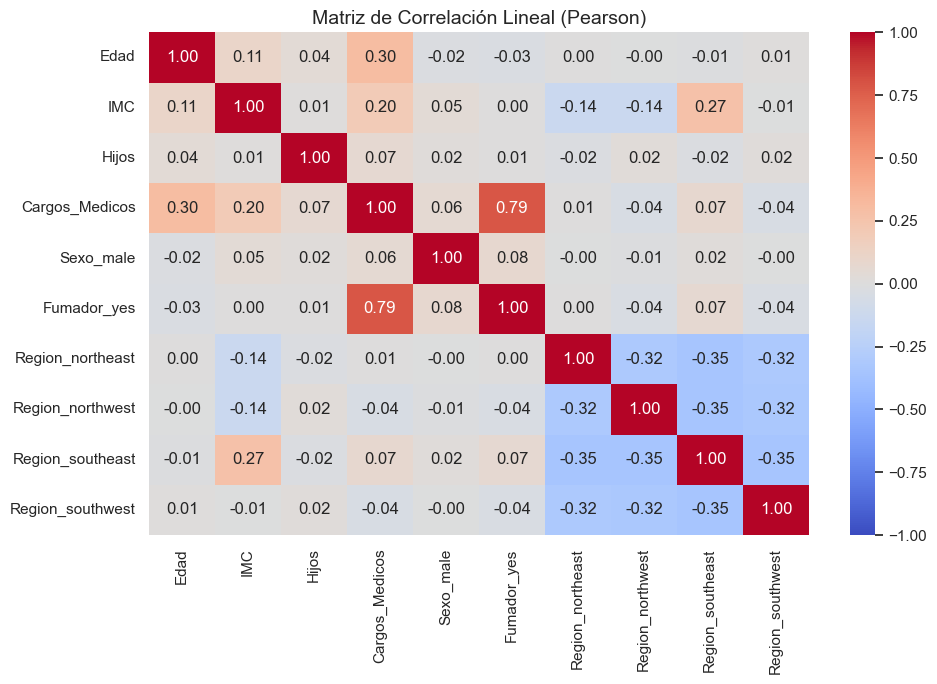

In [9]:
plt.figure(figsize=(10, 7))

# Calcular la matriz de correlación
matriz_corr = df.corr()

# Graficar el mapa de calor (Heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación Lineal (Pearson)', fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Separamos las características (X) de la variable objetivo (y)
# Cargos_Medicos' es lo que queremos predecir. El resto son los predictores.
X = df.drop(columns=['Cargos_Medicos'])
y = df['Cargos_Medicos']

# Hacemos el Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Total de registros en la base: {df.shape[0]}")
print(f"Registros para ENTRENAR los modelos (X_train): {X_train.shape[0]}")
print(f"Registros para TESTEAR los modelos (X_test): {X_test.shape[0]}")
print(f"Cantidad de variables predictoras: {X_train.shape[1]}")

Total de registros en la base: 1338
Registros para ENTRENAR los modelos (X_train): 1070
Registros para TESTEAR los modelos (X_test): 268
Cantidad de variables predictoras: 9


### Modelo Base

In [11]:
# 1. Crear el modelo de Árbol de Decisión Base
arbol_base = DecisionTreeRegressor(
    max_depth=5,              # No dejamos que tenga más de 5 niveles de preguntas
    min_samples_leaf=10,       # Cada hoja final debe representar al menos a 10 clientes
    random_state=42
)
# 2. Entrenar el modelo con los datos de entrenamiento
arbol_base.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [12]:
# Entrenamiento
pred_train = arbol_base.predict(X_train)
pred_test = arbol_base.predict(X_test)

In [13]:
# Calculamos las métricas comparando contra los targets originales (y_train e y_test)
print("--- RENDIMIENTO DEL ÁRBOL DE DECISIÓN BASE ---")
print("\n[Métricas en ENTRENAMIENTO]")
print(f"R2 Score (Train): {r2_score(y_train, pred_train):.4f}")
print(f"Error Absoluto Medio (MAE Train): ${mean_absolute_error(y_train, pred_train):.2f}")
print(f"Error Cuadratico Medio (MSE Train): {mean_squared_error(y_train, pred_train):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Train): ${np.sqrt(mean_squared_error(y_train, pred_train)):.2f}")

print("\n[Métricas en TEST (Datos Nuevos)]")
print(f"R2 Score (Test): {r2_score(y_test, pred_test):.4f}")
print(f"Error Absoluto Medio (MAE Test): ${mean_absolute_error(y_test, pred_test):.2f}")
print(f"Error Cuadrado Medio (MSE Test): {mean_squared_error(y_test, pred_test):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Test): ${np.sqrt(mean_squared_error(y_test, pred_test)):.2f}")

--- RENDIMIENTO DEL ÁRBOL DE DECISIÓN BASE ---

[Métricas en ENTRENAMIENTO]
R2 Score (Train): 0.8744
Error Absoluto Medio (MAE Train): $2415.58
Error Cuadratico Medio (MSE Train): 18121225.10
Raiz del Error Cuadratico Medio (RMSE Train): $4256.90

[Métricas en TEST (Datos Nuevos)]
R2 Score (Test): 0.8672
Error Absoluto Medio (MAE Test): $2626.88
Error Cuadrado Medio (MSE Test): 20620524.44
Raiz del Error Cuadratico Medio (RMSE Test): $4540.98


### Random Forest

In [14]:
reg_rf = RandomForestRegressor(
    n_estimators=1000, # cantidad de árboles
    max_depth=5,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1) # esto hace que todos los procesadores trabajen en paralelo.
reg_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [15]:
# Generamos las predicciones crudas
pred_train_rf = reg_rf.predict(X_train)
pred_test_rf = reg_rf.predict(X_test)

In [16]:
print("--- RENDIMIENTO DE RANDOM FOREST ---")
print("\n[Métricas en ENTRENAMIENTO]")
print(f"R2 Score (Train): {r2_score(y_train, pred_train_rf):.4f}")
print(f"Error Absoluto Medio (MAE Train): ${mean_absolute_error(y_train, pred_train_rf):.2f}")
print(f"Error Cuadratico Medio (MSE Train): {mean_squared_error(y_train, pred_train_rf):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Train): ${np.sqrt(mean_squared_error(y_train, pred_train_rf)):.2f}")

print("\n[Métricas en TEST (Datos Nuevos)]")
print(f"R2 Score (Test): {r2_score(y_test, pred_test_rf):.4f}")
print(f"Error Absoluto Medio (MAE Test): ${mean_absolute_error(y_test, pred_test_rf):.2f}")
print(f"Error Cuadrado Medio (MSE Test): {mean_squared_error(y_test, pred_test_rf):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Test): ${np.sqrt(mean_squared_error(y_test, pred_test_rf)):.2f}")

--- RENDIMIENTO DE RANDOM FOREST ---

[Métricas en ENTRENAMIENTO]
R2 Score (Train): 0.8783
Error Absoluto Medio (MAE Train): $2344.87
Error Cuadratico Medio (MSE Train): 17571034.22
Raiz del Error Cuadratico Medio (RMSE Train): $4191.78

[Métricas en TEST (Datos Nuevos)]
R2 Score (Test): 0.8785
Error Absoluto Medio (MAE Test): $2464.09
Error Cuadrado Medio (MSE Test): 18861341.05
Raiz del Error Cuadratico Medio (RMSE Test): $4342.96


### Ada-Boost

In [17]:
# AdaBoost típicamente usa árboles muy simples (stumps) con max_depth=1
reg_ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=1),  # Árbol débil (stump)
    n_estimators=1000,                               # Número de iteraciones
    learning_rate=0.001,                              # Contribución de cada árbol
    random_state=42
)

reg_ada.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeR...r(max_depth=1)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",1000
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.001
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not pro

In [18]:
# Generamos las predicciones crudas
pred_train_ada = reg_ada.predict(X_train)
pred_test_ada = reg_ada.predict(X_test)

In [19]:
print("--- RENDIMIENTO DE ADA BOOST ---")
print("\n[Métricas en ENTRENAMIENTO]")
print(f"R2 Score (Train): {r2_score(y_train, pred_train_ada):.4f}")
print(f"Error Absoluto Medio (MAE Train): ${mean_absolute_error(y_train, pred_train_ada):.2f}")
print(f"Error Cuadratico Medio (MSE Train): {mean_squared_error(y_train, pred_train_ada):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Train): ${np.sqrt(mean_squared_error(y_train, pred_train_ada)):.2f}")

print("\n[Métricas en TEST (Datos Nuevos)]")
print(f"R2 Score (Test): {r2_score(y_test, pred_test_ada):.4f}")
print(f"Error Absoluto Medio (MAE Test): ${mean_absolute_error(y_test, pred_test_ada):.2f}")
print(f"Error Cuadrado Medio (MSE Test): {mean_squared_error(y_test, pred_test_ada):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Test): ${np.sqrt(mean_squared_error(y_test, pred_test_ada)):.2f}")

--- RENDIMIENTO DE ADA BOOST ---

[Métricas en ENTRENAMIENTO]
R2 Score (Train): 0.6079
Error Absoluto Medio (MAE Train): $5741.04
Error Cuadratico Medio (MSE Train): 56597819.71
Raiz del Error Cuadratico Medio (RMSE Train): $7523.15

[Métricas en TEST (Datos Nuevos)]
R2 Score (Test): 0.6574
Error Absoluto Medio (MAE Test): $5699.74
Error Cuadrado Medio (MSE Test): 53195477.20
Raiz del Error Cuadratico Medio (RMSE Test): $7293.52


### Gradient Boosting

In [20]:
# Creamos el ensamble secuencial.
# n_estimators=100 significa que usaremos 100 árboles secuenciales.
# learning_rate=0.1 controla qué tan fuerte es la corrección de cada árbol (el tamaño del paso).
reg_gb = GradientBoostingRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    random_state=42)

reg_gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [21]:
# Generamos las predicciones crudas
pred_train_gb = reg_gb.predict(X_train)
pred_test_gb = reg_gb.predict(X_test)

In [22]:
print("--- RENDIMIENTO DE GRADIENT BOOSTING ---")
print("\n[Métricas en ENTRENAMIENTO]")
print(f"R2 Score (Train): {r2_score(y_train, pred_train_gb):.4f}")
print(f"Error Absoluto Medio (MAE Train): ${mean_absolute_error(y_train, pred_train_gb):.2f}")
print(f"Error Cuadratico Medio (MSE Train): {mean_squared_error(y_train, pred_train_gb):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Train): ${np.sqrt(mean_squared_error(y_train, pred_train_gb)):.2f}")

print("\n[Métricas en TEST (Datos Nuevos)]")
print(f"R2 Score (Test): {r2_score(y_test, pred_test_gb):.4f}")
print(f"Error Absoluto Medio (MAE Test): ${mean_absolute_error(y_test, pred_test_gb):.2f}")
print(f"Error Cuadrado Medio (MSE Test): {mean_squared_error(y_test, pred_test_gb):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Test): ${np.sqrt(mean_squared_error(y_test, pred_test_gb)):.2f}")

--- RENDIMIENTO DE GRADIENT BOOSTING ---

[Métricas en ENTRENAMIENTO]
R2 Score (Train): 0.9525
Error Absoluto Medio (MAE Train): $1429.21
Error Cuadratico Medio (MSE Train): 6858121.50
Raiz del Error Cuadratico Medio (RMSE Train): $2618.80

[Métricas en TEST (Datos Nuevos)]
R2 Score (Test): 0.8622
Error Absoluto Medio (MAE Test): $2493.86
Error Cuadrado Medio (MSE Test): 21386443.45
Raiz del Error Cuadratico Medio (RMSE Test): $4624.55


### Stacking

In [23]:
# Definimos los modelos con los mismos hiperparámetros que usamos antes
models = [
    ('arbol_base', DecisionTreeRegressor(random_state=42)),
    ('random_forest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('gradient_boosting', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
]

# Definimos al Gerente (Meta-Modelo). Ridge es una regresión lineal penalizada, ideal para esto.
master = Ridge()

stacking_model = StackingRegressor(estimators=models, final_estimator=master, cv=5, n_jobs=-1)
stacking_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('arbol_base', ...), ('random_forest', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, defa

In [24]:
pred_train_st = stacking_model.predict(X_train)
pred_test_st = stacking_model.predict(X_test)

In [25]:
print("--- RENDIMIENTO DE STACKING  ---")
print("\n[Métricas en ENTRENAMIENTO]")
print(f"R2 Score (Train): {r2_score(y_train, pred_train_st):.4f}")
print(f"Error Absoluto Medio (MAE Train): ${mean_absolute_error(y_train, pred_train_st):.2f}")
print(f"Error Cuadratico Medio (MSE Train): {mean_squared_error(y_train, pred_train_st):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Train): ${np.sqrt(mean_squared_error(y_train, pred_train_st)):.2f}")

print("\n[Métricas en TEST (Datos Nuevos)]")
print(f"R2 Score (Test): {r2_score(y_test, pred_test_st):.4f}")
print(f"Error Absoluto Medio (MAE Test): ${mean_absolute_error(y_test, pred_test_st):.2f}")
print(f"Error Cuadrado Medio (MSE Test): {mean_squared_error(y_test, pred_test_st):.2f}")
print(f"Raiz del Error Cuadratico Medio (RMSE Test): ${np.sqrt(mean_squared_error(y_test, pred_test_st)):.2f}")

--- RENDIMIENTO DE STACKING  ---

[Métricas en ENTRENAMIENTO]
R2 Score (Train): 0.9234
Error Absoluto Medio (MAE Train): $1800.22
Error Cuadratico Medio (MSE Train): 11059575.13
Raiz del Error Cuadratico Medio (RMSE Train): $3325.59

[Métricas en TEST (Datos Nuevos)]
R2 Score (Test): 0.8796
Error Absoluto Medio (MAE Test): $2367.59
Error Cuadrado Medio (MSE Test): 18693461.39
Raiz del Error Cuadratico Medio (RMSE Test): $4323.59


Existen diferentes Meta-Modelo para el stacking.

Para todos hay que probar y probar.

## Importancia de variables

In [26]:
# Extracción de importancias de modelos
df_importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Árbol Base': arbol_base.feature_importances_,
    'Random Forest': reg_rf.feature_importances_,
    'AdaBoost': reg_ada.feature_importances_,
    'Gradient Boosting': reg_gb.feature_importances_
})

# Extracción de importancias de meta-modelo stacking
nombres_modelos_base = [name for name, _ in models]
coeficientes_meta = stacking_model.final_estimator_.coef_

df_meta_importancia = pd.DataFrame({
    'Modelo Base': nombres_modelos_base,
    'Peso en el Stacking (Beta)': coeficientes_meta,
    'Peso Absoluto': np.abs(coeficientes_meta)
}).sort_values(by='Peso Absoluto', ascending=False)

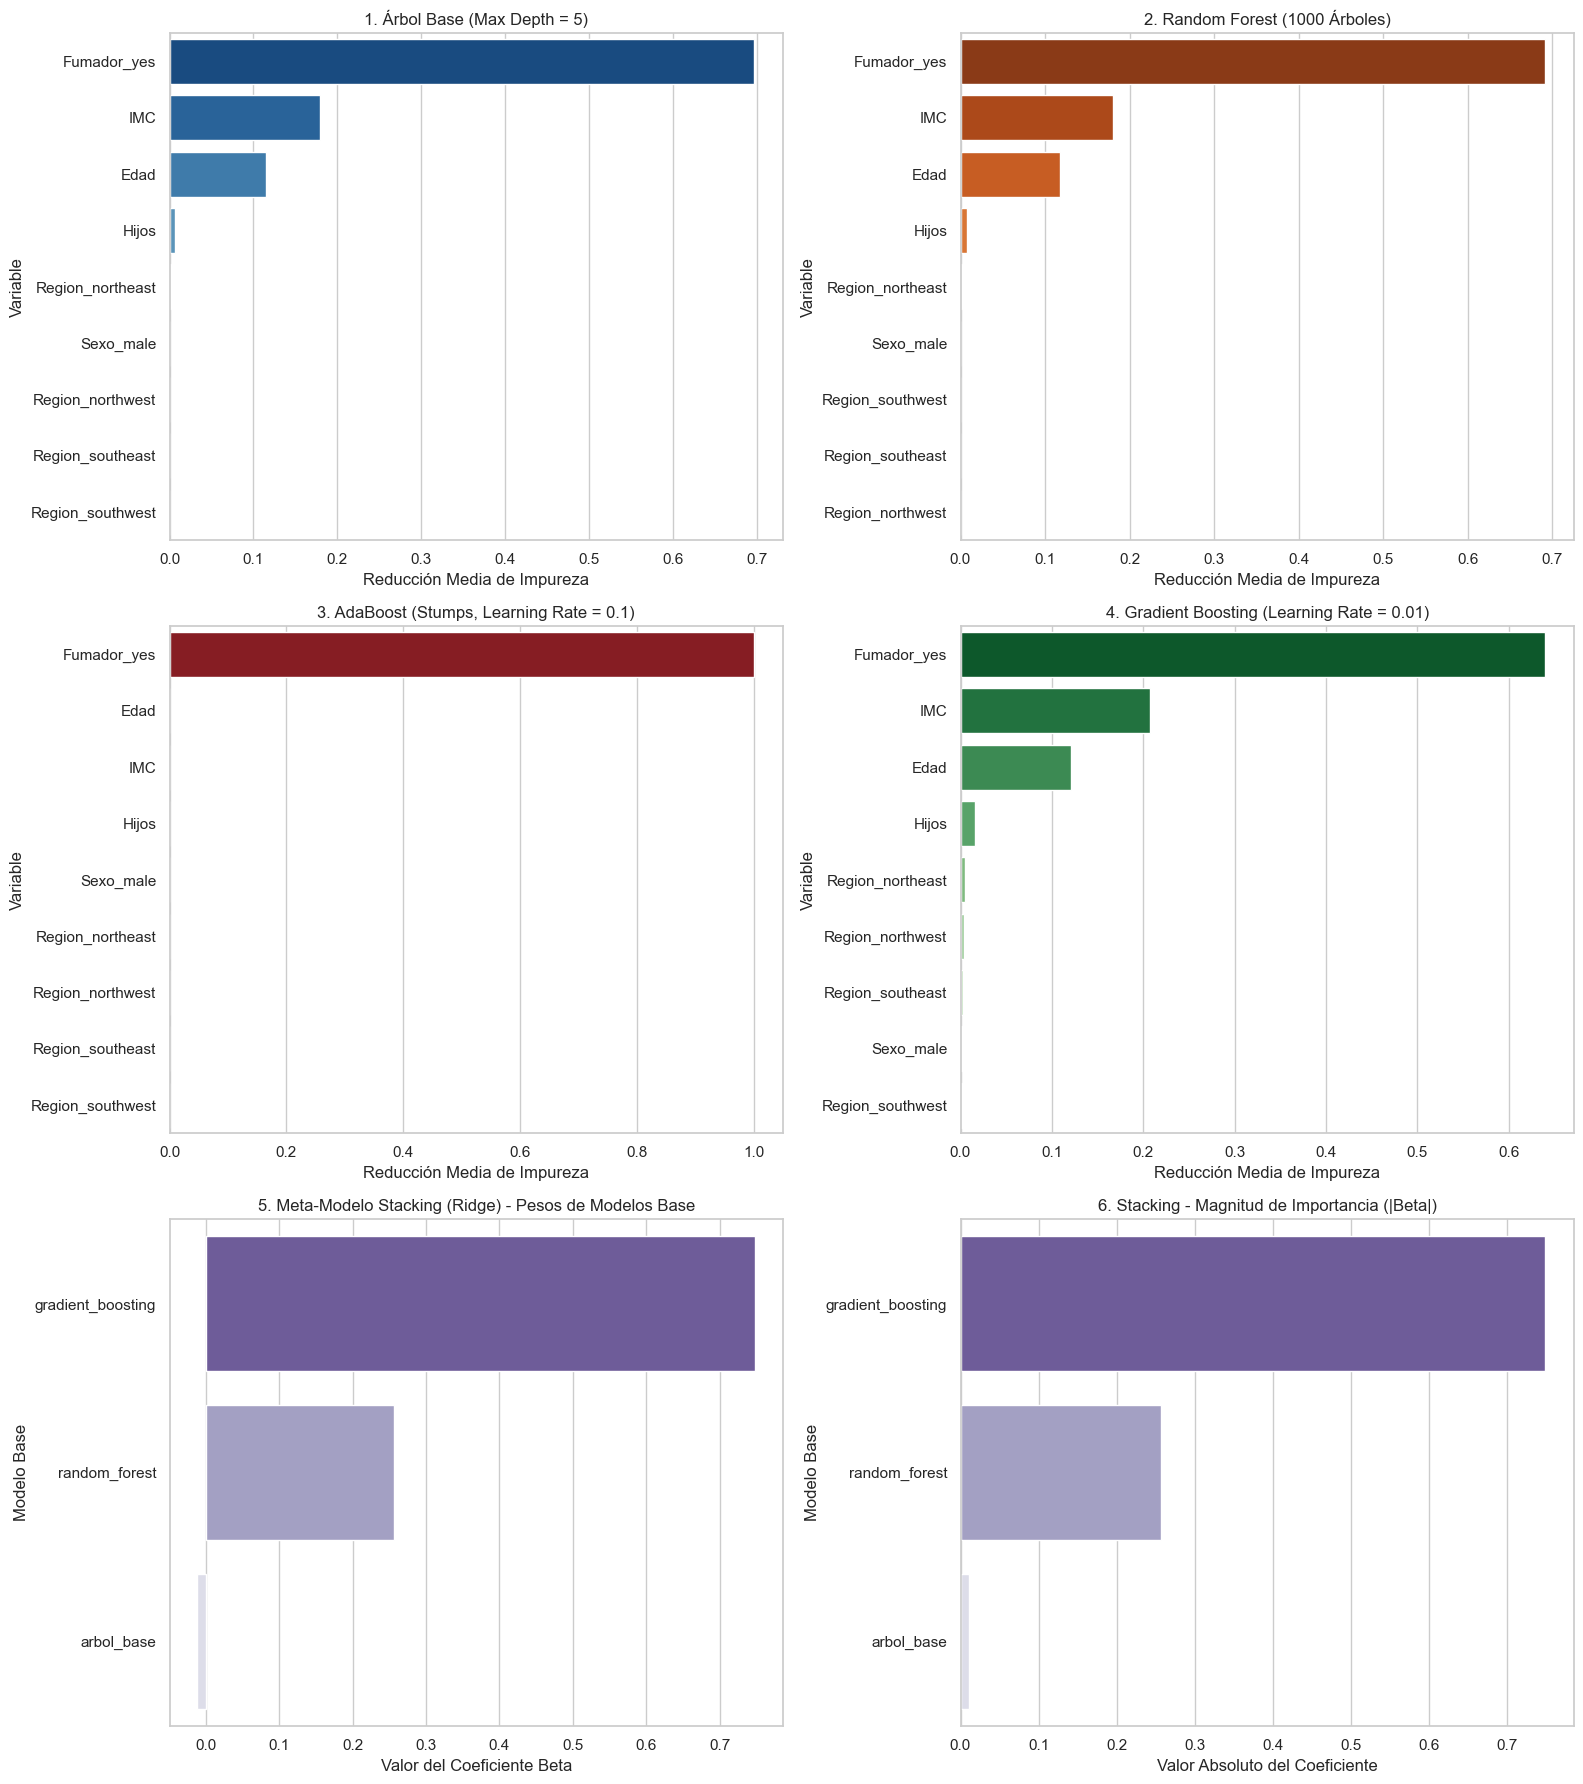

In [27]:
# Figura de 3 filas x 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# ==========================================
# Fila 1, Columna 0: Árbol de Decisión Base
# ==========================================
df_tree = df_importancias.sort_values(by='Árbol Base', ascending=False)
sns.barplot(
    data=df_tree,
    x='Árbol Base',
    y='Variable',
    hue='Variable',
    ax=axes[0, 0],
    palette='Blues_r',
    legend=False
)
axes[0, 0].set_title('1. Árbol Base (Max Depth = 5)')
axes[0, 0].set_xlabel('Reducción Media de Impureza')

# ==========================================
# Fila 1, Columna 1: Random Forest
# ==========================================
df_rf = df_importancias.sort_values(by='Random Forest', ascending=False)
sns.barplot(
    data=df_rf,
    x='Random Forest',
    y='Variable',
    hue='Variable',
    ax=axes[0, 1],
    palette='Oranges_r',
    legend=False
)
axes[0, 1].set_title('2. Random Forest (1000 Árboles)')
axes[0, 1].set_xlabel('Reducción Media de Impureza')

# ==========================================
# Fila 2, Columna 0: AdaBoost
# ==========================================
df_ada = df_importancias.sort_values(by='AdaBoost', ascending=False)
sns.barplot(
    data=df_ada,
    x='AdaBoost',
    y='Variable',
    hue='Variable',
    ax=axes[1, 0],
    palette='Reds_r',
    legend=False
)
axes[1, 0].set_title('3. AdaBoost (Stumps, Learning Rate = 0.1)')
axes[1, 0].set_xlabel('Reducción Media de Impureza')

# ==========================================
# Fila 2, Columna 1: Gradient Boosting
# ==========================================
df_gb = df_importancias.sort_values(by='Gradient Boosting', ascending=False)
sns.barplot(
    data=df_gb,
    x='Gradient Boosting',
    y='Variable',
    hue='Variable',
    ax=axes[1, 1],
    palette='Greens_r',
    legend=False
)
axes[1, 1].set_title('4. Gradient Boosting (Learning Rate = 0.01)')
axes[1, 1].set_xlabel('Reducción Media de Impureza')

# ==========================================
# Fila 3, Columna 0: Stacking (Pesos de modelos base)
# ==========================================
sns.barplot(
    data=df_meta_importancia,
    x='Peso en el Stacking (Beta)',
    y='Modelo Base',
    hue='Modelo Base',
    ax=axes[2, 0],
    palette='Purples_r',
    legend=False
)
axes[2, 0].set_title('5. Meta-Modelo Stacking (Ridge) - Pesos de Modelos Base')
axes[2, 0].set_xlabel('Valor del Coeficiente Beta')

# ==========================================
# Fila 3, Columna 1: Stacking (Pesos absolutos ordenados)
# ==========================================
sns.barplot(
    data=df_meta_importancia,
    x='Peso Absoluto',
    y='Modelo Base',
    hue='Modelo Base',
    ax=axes[2, 1],
    palette='Purples_r',
    legend=False
)
axes[2, 1].set_title('6. Stacking - Magnitud de Importancia (|Beta|)')
axes[2, 1].set_xlabel('Valor Absoluto del Coeficiente')

plt.tight_layout()
plt.show()

In [28]:
print("--- IMPORTANCIA DE VARIABLES EN MODELOS BASE ---")
print(df_importancias.round(4).to_string(index=False))
print("\n--- PESOS ASIGNADOS POR EL GERENTE (META-MODELO RIDGE) ---")
print(df_meta_importancia.round(4).to_string(index=False))

--- IMPORTANCIA DE VARIABLES EN MODELOS BASE ---
        Variable  Árbol Base  Random Forest  AdaBoost  Gradient Boosting
            Edad      0.1151         0.1176       0.0             0.1215
             IMC      0.1796         0.1801       0.0             0.2079
           Hijos      0.0063         0.0079       0.0             0.0158
       Sexo_male      0.0009         0.0006       0.0             0.0021
     Fumador_yes      0.6959         0.6909       1.0             0.6393
Region_northeast      0.0022         0.0017       0.0             0.0053
Region_northwest      0.0000         0.0003       0.0             0.0033
Region_southeast      0.0000         0.0004       0.0             0.0029
Region_southwest      0.0000         0.0005       0.0             0.0019

--- PESOS ASIGNADOS POR EL GERENTE (META-MODELO RIDGE) ---
      Modelo Base  Peso en el Stacking (Beta)  Peso Absoluto
gradient_boosting                      0.7483         0.7483
    random_forest                      